In [2]:
%pylab inline
import pandas as pd
import numpy as np

df = pd.read_csv("/voyager-hackathon/dataland/af3-dev/release_data/indices/md0805_test1_ligand_prot.csv")

df.head()

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


,entity_1_id,chain_1_id,mol_1_type,cluster_1_id,entity_2_id,chain_2_id,mol_2_type,cluster_2_id,cluster_id,pdb_id,assembly_id,release_date,num_tokens,num_prot_chains,resolution,type,mol_type_group,sub_mol_1_type,sub_mol_2_type,eval_type
0,1,X,ligand,1db4,2.0,A,prot,NotInClusterTxt,1db4:NotInClusterTxt,1db4_c3,NaN,9999-12-31,153,1,-1.0,interface,ligand_prot,non_bonded_ligand,prot,ligand_prot
1,1,X,ligand,1d4t,2.0,A,prot,NotInClusterTxt,1d4t:NotInClusterTxt,1d4t_c9,NaN,9999-12-31,194,1,-1.0,interface,ligand_prot,non_bonded_ligand,prot,ligand_prot
2,1,X,ligand,1db4,2.0,A,prot,NotInClusterTxt,1db4:NotInClusterTxt,1db4_c7,NaN,9999-12-31,153,1,-1.0,interface,ligand_prot,non_bonded_ligand,prot,ligand_prot
3,1,X,ligand,1ctr,2.0,A,prot,NotInClusterTxt,1ctr:NotInClusterTxt,1ctr_c1,NaN,9999-12-31,170,1,-1.0,interface,ligand_prot,non_bonded_ligand,prot,ligand_prot
4,1,X,ligand,1e3v,2.0,A,prot,NotInClusterTxt,1e3v:NotInClusterTxt,1e3v_c7,NaN,9999-12-31,285,2,-1.0,interface,ligand_prot,non_bonded_ligand,prot,ligand_prot


In [3]:
# sample 100 raws from df

sampled_df = df.sample(n=100, random_state=42)
sampled_df.head()


,entity_1_id,chain_1_id,mol_1_type,cluster_1_id,entity_2_id,chain_2_id,mol_2_type,cluster_2_id,cluster_id,pdb_id,assembly_id,release_date,num_tokens,num_prot_chains,resolution,type,mol_type_group,sub_mol_1_type,sub_mol_2_type,eval_type
1091,1,X,ligand,1f3j,3.0,B,prot,NotInClusterTxt,1f3j:NotInClusterTxt,1f3j_c5,NaN,9999-12-31,855,4,-1.0,interface,ligand_prot,non_bonded_ligand,prot,ligand_prot
898,1,X,ligand,1h3h,2.0,A,prot,NotInClusterTxt,1h3h:NotInClusterTxt,1h3h_c3,NaN,9999-12-31,140,1,-1.0,interface,ligand_prot,non_bonded_ligand,prot,ligand_prot
739,1,X,ligand,1gni,2.0,A,prot,NotInClusterTxt,1gni:NotInClusterTxt,1gni_c10,NaN,9999-12-31,602,1,-1.0,interface,ligand_prot,non_bonded_ligand,prot,ligand_prot
140,1,X,ligand,1gni,2.0,A,prot,NotInClusterTxt,1gni:NotInClusterTxt,1gni_c4,NaN,9999-12-31,602,1,-1.0,interface,ligand_prot,non_bonded_ligand,prot,ligand_prot
1019,1,X,ligand,1dfo,3.0,B,prot,NotInClusterTxt,1dfo:NotInClusterTxt,1dfo_c3,NaN,9999-12-31,867,2,-1.0,interface,ligand_prot,non_bonded_ligand,prot,ligand_prot


In [4]:
sampled_df.to_csv("/voyager-hackathon/home/hms/code/Protenix/mydata/md0805_test1_ligand_prot_sampled.csv", index=False)

In [3]:
trainidx = pd.read_csv("/voyager-hackathon/dataland/af3-dev/release_data/indices/md0805_training.csv")

In [8]:
trainidx[trainidx.eval_type == "ligand_prot"].to_csv("/voyager-hackathon/home/hms/code/Protenix/mydata/md0805_training_ligand_prot.csv", index=False)

In [4]:
cleanlp = trainidx[trainidx.eval_type == "ligand_prot"].copy()

In [ ]:
plt.hist(cleanlp.num_tokens)

(array([8438., 6042., 3264.,  952.,  580.,  180.,   70.,    0.,    0.,
         101.]),
 array([  70. ,  378.2,  686.4,  994.6, 1302.8, 1611. , 1919.2, 2227.4,
        2535.6, 2843.8, 3152. ]),
 <BarContainer object of 10 artists>)

In [21]:
cleanlp.groupby("pdb_id").apply(lambda x: x.iloc[0]).to_csv("/voyager-hackathon/home/hms/code/Protenix/mydata/md0805_training_ligand_prot_clean.csv", index=False)

/tmp/ipykernel_203940/728884076.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cleanlp.groupby("pdb_id").apply(lambda x: x.iloc[0]).to_csv("/voyager-hackathon/home/hms/code/Protenix/mydata/md0805_training_ligand_prot_clean.csv", index=False)


In [10]:
cleanligprot = pd.read_csv("/voyager-hackathon/home/hms/code/Protenix/mydata/md0805_training_ligand_prot_clean.csv")

In [14]:
import pickle
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import gzip

cleanligprot = pd.read_csv("/voyager-hackathon/home/hms/code/Protenix/mydata/md0805_training_ligand_prot_clean.csv")
weights = []
for x in tqdm(cleanligprot.iterrows()):
    with gzip.open(f"/voyager-hackathon/dataland/af3-dev/release_data/md0805_training_bioassembly/{x[1]['pdb_id']}.pkl.gz", "rb") as f:
        bioassembly_dict = pickle.load(f)
    weights.append(bioassembly_dict['conf_density'])

plt.hist(weights)

0it [00:00, ?it/s]

16139it [05:20, 50.30it/s] 


(array([6.213e+03, 6.787e+03, 2.459e+03, 5.410e+02, 1.050e+02, 2.800e+01,
        4.000e+00, 1.000e+00, 0.000e+00, 1.000e+00]),
 array([0.002 , 0.0745, 0.147 , 0.2195, 0.292 , 0.3645, 0.437 , 0.5095,
        0.582 , 0.6545, 0.727 ]),
 <BarContainer object of 10 artists>)

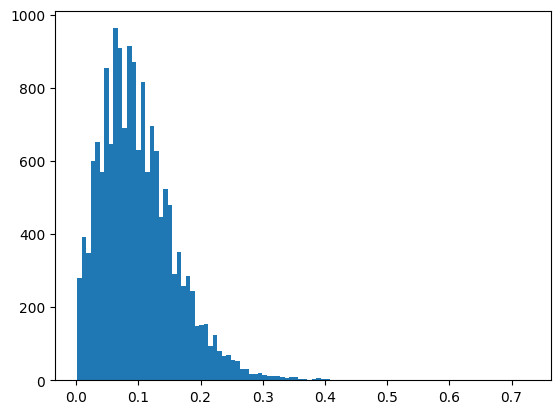

In [22]:
plt.figure()
plt.hist(weights,bins=100)
plt.show()

In [15]:
cleanligprot['weights'] = weights

In [23]:
cleanligprot.to_csv("/voyager-hackathon/home/hms/code/Protenix/mydata/md0805_training_ligand_prot_clean_weights.csv",index=False)